In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [8]:
%matplotlib inline

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
import time
import json
import os
from datetime import timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

os.makedirs('saved_models', exist_ok=True)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU available: {gpus}")
else:
    print("No GPU — running on CPU")

print(f"TensorFlow : {tf.__version__}")
print("All imports done")

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow : 2.19.0
All imports done


In [9]:
start_load = time.time()

interaction_data = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.20s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


In [10]:
df_merged = interaction_data.copy()

# Merge user profiles
df_merged = df_merged.merge(
    user_profiles[['user_id','type','location',
                   'preferences','preferred_presentation_type']],
    on='user_id',
    how='left',
    suffixes=('','_user')
)

# Merge recommendations (article level info)
df_merged = df_merged.merge(
    recommendations[['article_id','presentation_type',
                     'audience_type','Main issue','popularity']],
    on='article_id',
    how='left',
    suffixes=('','_rec')
)

print(f"df_merged shape : {df_merged.shape}")
print(f"\nKey columns confirmed:")
print(f"  preferred_presentation_type : {'preferred_presentation_type' in df_merged.columns}")
print(f"  audience_type               : {'audience_type' in df_merged.columns}")
print(f"  presentation_type           : {'presentation_type' in df_merged.columns}")
print(f"  type (user type)            : {'type' in df_merged.columns}")

df_merged shape : (25000, 83)

Key columns confirmed:
  preferred_presentation_type : True
  audience_type               : True
  presentation_type           : True
  type (user type)            : True


In [11]:
# ── User feature columns ──────────────────────────────────
USER_FEAT_COLS = [
    'user_preference_Boring presentation','user_preference_Graphics',
    'user_preference_Readability','user_preference_Consistency',
    'user_preference_Images','user_preference_Bullets',
    'user_preference_Text size','user_preference_Text heavy',
    'user_preference_Tables','user_preference_Agenda',
    'user_preference_Infographics','user_preference_Positioning',
    'user_preference_Presentation length','user_preference_General tips',
    'user_preference_Presentation skills',
    'user_preference_Powerpoint knowledge',
    'user_preference_tips and tricks',
    'user_preference_Explanation of the problem',
    'user_type_business','user_type_teacher','user_type_student',
    'user_type_researcher','user_type_manager',
    'user_type_technical','user_type_specialist',
    'presentation_type_formal_x','presentation_type_creative_x',
    'presentation_type_business_x','presentation_type_educational_x',
    'presentation_type_technical_x','presentation_type_persuasive_x'
]

# ── Item feature columns ──────────────────────────────────
ITEM_FEAT_COLS = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning','Presentation length','General tips',
    'Presentation skills','Powerpoint knowledge','tips and tricks',
    'Explanation of the problem',
    'presentation_type_formal_y','presentation_type_creative_y',
    'presentation_type_business_y','presentation_type_educational_y',
    'presentation_type_technical_y','presentation_type_persuasive_y',
    'audience_type_academic','audience_type_business',
    'audience_type_technical','audience_type_kids','audience_type_general'
]

# ── Problem sequence columns ──────────────────────────────
PROBLEM_COLS = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning'
]

# Only keep columns that actually exist in the dataframe
USER_FEAT_COLS = [c for c in USER_FEAT_COLS if c in interaction_data.columns]
ITEM_FEAT_COLS = [c for c in ITEM_FEAT_COLS if c in interaction_data.columns]
PROBLEM_COLS   = [c for c in PROBLEM_COLS   if c in interaction_data.columns]

print(f"User features  : {len(USER_FEAT_COLS)}")
print(f"Item features  : {len(ITEM_FEAT_COLS)}")
print(f"Problem cols   : {len(PROBLEM_COLS)}")
print(f"\nUser feature columns:")
for c in USER_FEAT_COLS:
    print(f"  {c}")
print(f"\nItem feature columns:")
for c in ITEM_FEAT_COLS:
    print(f"  {c}")

User features  : 31
Item features  : 29
Problem cols   : 12

User feature columns:
  user_preference_Boring presentation
  user_preference_Graphics
  user_preference_Readability
  user_preference_Consistency
  user_preference_Images
  user_preference_Bullets
  user_preference_Text size
  user_preference_Text heavy
  user_preference_Tables
  user_preference_Agenda
  user_preference_Infographics
  user_preference_Positioning
  user_preference_Presentation length
  user_preference_General tips
  user_preference_Presentation skills
  user_preference_Powerpoint knowledge
  user_preference_tips and tricks
  user_preference_Explanation of the problem
  user_type_business
  user_type_teacher
  user_type_student
  user_type_researcher
  user_type_manager
  user_type_technical
  user_type_specialist
  presentation_type_formal_x
  presentation_type_creative_x
  presentation_type_business_x
  presentation_type_educational_x
  presentation_type_technical_x
  presentation_type_persuasive_x

Item fea

In [12]:
print("Feature engineering...")

df_fe = interaction_data.copy()
df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'])
df_fe = df_fe.sort_values('timestamp').reset_index(drop=True)

# ── Cyclic time features ──────────────────────────────────
df_fe['hour']  = df_fe['timestamp'].dt.hour
df_fe['dow']   = df_fe['timestamp'].dt.dayofweek
df_fe['month'] = df_fe['timestamp'].dt.month

df_fe['hour_sin']  = np.sin(2*np.pi*df_fe['hour']/24)
df_fe['hour_cos']  = np.cos(2*np.pi*df_fe['hour']/24)
df_fe['day_sin']   = np.sin(2*np.pi*df_fe['dow']/7)
df_fe['day_cos']   = np.cos(2*np.pi*df_fe['dow']/7)
df_fe['month_sin'] = np.sin(2*np.pi*df_fe['month']/12)
df_fe['month_cos'] = np.cos(2*np.pi*df_fe['month']/12)

# Hours since first interaction per user
first_ts = df_fe.groupby('user_id')['timestamp'].transform('min')
df_fe['hours_since_first'] = (
    (df_fe['timestamp'] - first_ts).dt.total_seconds() / 3600
)

# ── User activity stats ───────────────────────────────────
user_stats = df_fe.groupby('user_id').agg(
    user_avg_rating   = ('rating','mean'),
    user_rating_count = ('rating','count'),
    user_rating_std   = ('rating','std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df_fe = df_fe.merge(user_stats, on='user_id', how='left')

# ── Item activity stats ───────────────────────────────────
item_stats = df_fe.groupby('article_id').agg(
    item_avg_rating   = ('rating','mean'),
    item_rating_count = ('rating','count'),
    item_rating_std   = ('rating','std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df_fe = df_fe.merge(item_stats, on='article_id', how='left')

# ── Exponential decay weights ─────────────────────────────
decay = 0.01
df_fe['decay_weight'] = np.exp(-decay * df_fe['hours_since_first'] / 24)
for col in PROBLEM_COLS:
    if col in df_fe.columns:
        df_fe[f'weighted_{col}'] = df_fe[col] * df_fe['decay_weight']

# ── Define final feature group names ─────────────────────
TIME_COLS = ['hour_sin','hour_cos','day_sin','day_cos','hours_since_first']
PROB_COLS = [f'weighted_{c}' for c in PROBLEM_COLS
             if f'weighted_{c}' in df_fe.columns]

# ── Normalize continuous columns ──────────────────────────
scaler        = MinMaxScaler()
cols_to_scale = (TIME_COLS + PROB_COLS +
                 ['user_avg_rating','user_rating_count','user_rating_std',
                  'item_avg_rating','item_rating_count','item_rating_std'])
cols_to_scale = [c for c in cols_to_scale if c in df_fe.columns]
df_fe[cols_to_scale] = scaler.fit_transform(
    df_fe[cols_to_scale].fillna(0)
)

# Fill all feature cols with 0 if any missing
for col in USER_FEAT_COLS + ITEM_FEAT_COLS:
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].fillna(0)

print(f"Feature engineering done")
print(f"Final df_fe shape : {df_fe.shape}")
print(f"TIME_COLS         : {TIME_COLS}")
print(f"PROB_COLS count   : {len(PROB_COLS)}")

Feature engineering...
Feature engineering done
Final df_fe shape : (25000, 104)
TIME_COLS         : ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'hours_since_first']
PROB_COLS count   : 12


In [13]:
print("="*60)
print("MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK")
print("="*60)

# These are the exact column groups used by Model 4 and Model 5
USER_COLS = [c for c in interaction_data.columns
             if c.startswith('user_preference_')
             or c.startswith('user_type_')
             or (c.startswith('presentation_type_') and c.endswith('_x'))]

ITEM_COLS = [c for c in interaction_data.columns
             if c in ['Boring presentation','Graphics','Readability',
                      'Consistency','Images','Bullets','Text size',
                      'Text heavy','Tables','Agenda','Infographics',
                      'Positioning','Presentation length','General tips',
                      'Presentation skills','Powerpoint knowledge',
                      'tips and tricks','Explanation of the problem']
             or (c.startswith('presentation_type_') and c.endswith('_y'))
             or c.startswith('audience_type_')]

PROBLEM_COLS = [c for c in interaction_data.columns
                if c in ['Boring presentation','Graphics','Readability',
                         'Consistency','Images','Bullets','Text size',
                         'Text heavy','Tables','Agenda','Infographics',
                         'Positioning']]

print(f"USER_COLS  : {len(USER_COLS)}")
print(f"ITEM_COLS  : {len(ITEM_COLS)}")
print(f"PROBLEM_COLS: {len(PROBLEM_COLS)}")
print("\nAll feature groups defined for Model 4 and Model 5")

MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK
USER_COLS  : 31
ITEM_COLS  : 36
PROBLEM_COLS: 12

All feature groups defined for Model 4 and Model 5


In [14]:
df_h = interaction_data.copy()
df_h['timestamp'] = pd.to_datetime(df_h['timestamp'])
df_h = df_h.sort_values('timestamp').reset_index(drop=True)

# Cyclic time features
df_h['hour'] = df_h['timestamp'].dt.hour
df_h['dow']  = df_h['timestamp'].dt.dayofweek

df_h['hour_sin'] = np.sin(2*np.pi*df_h['hour']/24)
df_h['hour_cos'] = np.cos(2*np.pi*df_h['hour']/24)
df_h['day_sin']  = np.sin(2*np.pi*df_h['dow']/7)
df_h['day_cos']  = np.cos(2*np.pi*df_h['dow']/7)

# Hours since first interaction
first_ts = df_h.groupby('user_id')['timestamp'].transform('min')
df_h['hours_since_first'] = (
    (df_h['timestamp'] - first_ts).dt.total_seconds() / 3600
)

# Exponential decay weights (paper's approach)
decay = 0.01
df_h['decay_weight'] = np.exp(-decay * df_h['hours_since_first'] / 24)
for col in PROBLEM_COLS:
    if col in df_h.columns:
        df_h[f'weighted_{col}'] = df_h[col] * df_h['decay_weight']

# Define time and problem feature names
TIME_COLS = ['hour_sin','hour_cos','day_sin','day_cos','hours_since_first']
PROB_COLS = [f'weighted_{c}' for c in PROBLEM_COLS
             if f'weighted_{c}' in df_h.columns]

# Normalize
scaler_h = MinMaxScaler()
cols_scale = TIME_COLS + PROB_COLS
df_h[cols_scale] = scaler_h.fit_transform(
    df_h[cols_scale].fillna(0)
)

# Fill all feature cols
for col in USER_COLS + ITEM_COLS:
    if col in df_h.columns:
        df_h[col] = df_h[col].fillna(0)

print(f"df_h shape   : {df_h.shape}")
print(f"TIME_COLS    : {TIME_COLS}")
print(f"PROB_COLS    : {len(PROB_COLS)} columns")

df_h shape   : (25000, 95)
TIME_COLS    : ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'hours_since_first']
PROB_COLS    : 12 columns


In [15]:
# Build numpy arrays for all 4 input towers
X_user = df_h[USER_COLS].values.astype(np.float32)
X_item = df_h[ITEM_COLS].values.astype(np.float32)
X_time = df_h[TIME_COLS].values.astype(np.float32)
X_prob = df_h[PROB_COLS].values.astype(np.float32)
y      = df_h['rating'].values.astype(np.float32)

# 70 / 15 / 15 split
idx = np.arange(len(y))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

def split_arr(arr):
    return arr[train_idx], arr[val_idx], arr[test_idx]

Xu_tr, Xu_va, Xu_te = split_arr(X_user)
Xi_tr, Xi_va, Xi_te = split_arr(X_item)
Xt_tr, Xt_va, Xt_te = split_arr(X_time)
Xp_tr, Xp_va, Xp_te = split_arr(X_prob)
y_tr,  y_va,  y_te  = split_arr(y)

print(f"Train : {len(y_tr):,} | Val : {len(y_va):,} | Test : {len(y_te):,}")
print(f"\nArray shapes:")
print(f"  Xu_tr : {Xu_tr.shape}  (user features)")
print(f"  Xi_tr : {Xi_tr.shape}  (item features)")
print(f"  Xt_tr : {Xt_tr.shape}  (time features)")
print(f"  Xp_tr : {Xp_tr.shape}  (problem features)")
print(f"  y_tr  : {y_tr.shape}   (ratings)")

Train : 17,500 | Val : 3,750 | Test : 3,750

Array shapes:
  Xu_tr : (17500, 31)  (user features)
  Xi_tr : (17500, 36)  (item features)
  Xt_tr : (17500, 5)  (time features)
  Xp_tr : (17500, 12)  (problem features)
  y_tr  : (17500,)   (ratings)


In [16]:
print("Final check — all variables ready for Model 5:")
print("="*55)

checks = {
    'USER_COLS' : USER_COLS,
    'ITEM_COLS' : ITEM_COLS,
    'TIME_COLS' : TIME_COLS,
    'PROB_COLS' : PROB_COLS,
    'Xu_tr'     : Xu_tr,  'Xu_va': Xu_va, 'Xu_te': Xu_te,
    'Xi_tr'     : Xi_tr,  'Xi_va': Xi_va, 'Xi_te': Xi_te,
    'Xt_tr'     : Xt_tr,  'Xt_va': Xt_va, 'Xt_te': Xt_te,
    'Xp_tr'     : Xp_tr,  'Xp_va': Xp_va, 'Xp_te': Xp_te,
    'y_tr'      : y_tr,   'y_va' : y_va,  'y_te' : y_te,
}

all_good = True
for name, var in checks.items():
    shape = var.shape if hasattr(var, 'shape') else len(var)
    print(f"  ✅  {name:<15} {shape}")

print("="*55)
print("ALL READY — now run Cell M5-1 onwards")


Final check — all variables ready for Model 5:
  ✅  USER_COLS       31
  ✅  ITEM_COLS       36
  ✅  TIME_COLS       5
  ✅  PROB_COLS       12
  ✅  Xu_tr           (17500, 31)
  ✅  Xu_va           (3750, 31)
  ✅  Xu_te           (3750, 31)
  ✅  Xi_tr           (17500, 36)
  ✅  Xi_va           (3750, 36)
  ✅  Xi_te           (3750, 36)
  ✅  Xt_tr           (17500, 5)
  ✅  Xt_va           (3750, 5)
  ✅  Xt_te           (3750, 5)
  ✅  Xp_tr           (17500, 12)
  ✅  Xp_va           (3750, 12)
  ✅  Xp_te           (3750, 12)
  ✅  y_tr            (17500,)
  ✅  y_va            (3750,)
  ✅  y_te            (3750,)
ALL READY — now run Cell M5-1 onwards


In [17]:
print("="*60)
print("MODEL 5: HYBRID + CUSTOM PRE-TRAINED EMBEDDINGS")
print("="*60)

os.makedirs('saved_models', exist_ok=True)

# We reuse df_h, USER_COLS, ITEM_COLS, TIME_COLS, PROB_COLS
# and the same train/val/test split indices from Model 4
# so make sure Model 4 cells ran first

print(f"User dim  : {len(USER_COLS)}")
print(f"Item dim  : {len(ITEM_COLS)}")
print(f"Time dim  : {len(TIME_COLS)}")
print(f"Prob dim  : {len(PROB_COLS)}")
print(f"Train rows: {len(y_tr):,}")
print(f"Val rows  : {len(y_va):,}")
print(f"Test rows : {len(y_te):,}")

MODEL 5: HYBRID + CUSTOM PRE-TRAINED EMBEDDINGS
User dim  : 31
Item dim  : 36
Time dim  : 5
Prob dim  : 12
Train rows: 17,500
Val rows  : 3,750
Test rows : 3,750


In [18]:
def build_embedding_ae(input_dim, embed_dim=16, name='ae'):
    """Small autoencoder to learn compact embeddings."""
    inp     = Input(shape=(input_dim,), name=f'{name}_input')
    x       = layers.Dense(64,  activation='relu')(inp)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.2)(x)
    encoded = layers.Dense(embed_dim, activation='relu',
                            name=f'{name}_embed')(x)
    x       = layers.Dense(64,  activation='relu')(encoded)
    x       = layers.BatchNormalization()(x)
    decoded = layers.Dense(input_dim, activation='sigmoid')(x)

    ae = Model(inp, decoded, name=f'{name}_autoencoder')
    ae.compile(optimizer='adam', loss='mse')
    return ae

# ── Pre-train user embedding AE ───────────────────────────
print("Pre-training user embedding autoencoder...")
user_ae = build_embedding_ae(len(USER_COLS), embed_dim=16, name='user')
user_ae.fit(
    Xu_tr, Xu_tr,
    validation_data=(Xu_va, Xu_va),
    epochs=50, batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=0)],
    verbose=1
)

# ── Pre-train item embedding AE ───────────────────────────
print("\nPre-training item embedding autoencoder...")
item_ae = build_embedding_ae(len(ITEM_COLS), embed_dim=16, name='item')
item_ae.fit(
    Xi_tr, Xi_tr,
    validation_data=(Xi_va, Xi_va),
    epochs=50, batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=0)],
    verbose=1
)

# ── Extract encoder parts ─────────────────────────────────
user_encoder = Model(user_ae.input,
                     user_ae.get_layer('user_embed').output,
                     name='user_encoder')
item_encoder = Model(item_ae.input,
                     item_ae.get_layer('item_embed').output,
                     name='item_encoder')

# ── Generate embeddings for all splits ───────────────────
print("\nGenerating embeddings...")
Xu_emb_tr = user_encoder.predict(Xu_tr, batch_size=512, verbose=0)
Xu_emb_va = user_encoder.predict(Xu_va, batch_size=512, verbose=0)
Xu_emb_te = user_encoder.predict(Xu_te, batch_size=512, verbose=0)

Xi_emb_tr = item_encoder.predict(Xi_tr, batch_size=512, verbose=0)
Xi_emb_va = item_encoder.predict(Xi_va, batch_size=512, verbose=0)
Xi_emb_te = item_encoder.predict(Xi_te, batch_size=512, verbose=0)

print(f"User embedding shape : {Xu_emb_tr.shape}")
print(f"Item embedding shape : {Xi_emb_tr.shape}")

# Save encoders
user_encoder.save('saved_models/user_encoder.keras')
item_encoder.save('saved_models/item_encoder.keras')
print("\nSaved user_encoder and item_encoder")

Pre-training user embedding autoencoder...


I0000 00:00:1774171791.204526      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774171791.210448      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1774171794.883656     209 service.cc:152] XLA service 0x7fe96800cd70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774171794.883690     209 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774171794.883694     209 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774171795.401411     209 cuda_dnn.cc:529] Loaded cuDNN version 91002


50/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2606

I0000 00:00:1774171797.332234     209 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2496 - val_loss: 0.1909
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1319 - val_loss: 0.0953
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0525 - val_loss: 0.0564
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0235 - val_loss: 0.0332
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - val_loss: 0.0153
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078 - val_loss: 0.0062
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - val_loss: 0.0029
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 7.9372e-04
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 5.8545e-04
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - val_loss

In [19]:
# Combined input:
# user_embedding (16) + item_embedding (16) + time (5) + problem (12)

Xc_tr = np.hstack([Xu_emb_tr, Xi_emb_tr, Xt_tr, Xp_tr]).astype(np.float32)
Xc_va = np.hstack([Xu_emb_va, Xi_emb_va, Xt_va, Xp_va]).astype(np.float32)
Xc_te = np.hstack([Xu_emb_te, Xi_emb_te, Xt_te, Xp_te]).astype(np.float32)

input_dim_m5 = Xc_tr.shape[1]

print(f"Combined input dim : {input_dim_m5}")
print(f"  User embed       : {Xu_emb_tr.shape[1]}")
print(f"  Item embed       : {Xi_emb_tr.shape[1]}")
print(f"  Time features    : {Xt_tr.shape[1]}")
print(f"  Problem features : {Xp_tr.shape[1]}")
print(f"Train shape : {Xc_tr.shape}")
print(f"Val shape   : {Xc_va.shape}")
print(f"Test shape  : {Xc_te.shape}")

Combined input dim : 49
  User embed       : 16
  Item embed       : 16
  Time features    : 5
  Problem features : 12
Train shape : (17500, 49)
Val shape   : (3750, 49)
Test shape  : (3750, 49)


In [20]:
def build_hybrid_emb_model(input_dim,
                            units=[128, 64, 32],
                            dropout=0.3,
                            lr=1e-3):
    """
    Prediction head on top of pre-trained embeddings.
    Takes combined embedding vector as input.
    """
    reg = tf.keras.regularizers.l2(1e-5)

    inp = Input(shape=(input_dim,), name='combined_input')
    x   = inp

    for i, u in enumerate(units):
        x = layers.Dense(u, activation='relu',
                          kernel_regularizer=reg,
                          name=f'dense_{i}')(x)
        x = layers.BatchNormalization(name=f'bn_{i}')(x)
        x = layers.Dropout(dropout, name=f'drop_{i}')(x)

    out = layers.Dense(1, activation='linear', name='output')(x)

    model = Model(inp, out, name='Hybrid_Embeddings')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Preview
preview_m5 = build_hybrid_emb_model(input_dim_m5)
preview_m5.summary()
print(f"\nTotal parameters: {preview_m5.count_params():,}")

Model: "Hybrid_Embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 17,665


In [21]:
print("="*60)
print("STEP 1: HYPERPARAMETER TUNING")
print("="*60)

configs_m5 = [
    {'units':[128,64,32], 'dropout':0.3, 'lr':1e-3},
    {'units':[128,64,32], 'dropout':0.2, 'lr':5e-4},
    {'units':[256,128,64],'dropout':0.3, 'lr':1e-3},
    {'units':[64, 32],    'dropout':0.2, 'lr':1e-3},
    {'units':[128,64],    'dropout':0.3, 'lr':5e-4},
]

tune_results_m5 = []

for i, cfg in enumerate(configs_m5):
    print(f"\nConfig {i+1}/{len(configs_m5)}: {cfg}")

    m = build_hybrid_emb_model(
        input_dim = input_dim_m5,
        units     = cfg['units'],
        dropout   = cfg['dropout'],
        lr        = cfg['lr']
    )

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    h = m.fit(
        Xc_tr, y_tr,
        validation_data=(Xc_va, y_va),
        epochs=20, batch_size=256,
        callbacks=[es], verbose=1
    )

    bvl   = min(h.history['val_loss'])
    bvmae = min(h.history['val_mae'])
    btl   = min(h.history['loss'])
    btmae = min(h.history['mae'])
    ep    = len(h.history['loss'])

    print(f"  Epochs     : {ep}")
    print(f"  Train loss : {btl:.4f} | Val loss : {bvl:.4f}")
    print(f"  Train MAE  : {btmae:.4f} | Val MAE  : {bvmae:.4f}")

    tune_results_m5.append({
        'config'    : cfg,
        'val_loss'  : bvl,
        'val_mae'   : bvmae,
        'train_loss': btl,
        'train_mae' : btmae,
        'epochs'    : ep
    })

print("\n" + "="*60)
print("TUNING SUMMARY")
print("="*60)
print(f"{'Cfg':<5}{'Train Loss':>12}{'Val Loss':>10}"
      f"{'Train MAE':>11}{'Val MAE':>9}{'Epochs':>7}")
print("-"*55)
for i, r in enumerate(tune_results_m5):
    print(f"  {i+1:<4}{r['train_loss']:>12.4f}{r['val_loss']:>10.4f}"
          f"{r['train_mae']:>11.4f}{r['val_mae']:>9.4f}{r['epochs']:>7}")

best_m5     = min(tune_results_m5, key=lambda x: x['val_mae'])
best_cfg_m5 = best_m5['config']
print(f"\nBest config  : {best_cfg_m5}")
print(f"Best val MAE : {best_m5['val_mae']:.4f}")

STEP 1: HYPERPARAMETER TUNING

Config 1/5: {'units': [128, 64, 32], 'dropout': 0.3, 'lr': 0.001}
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 10.0815 - mae: 2.8497 - val_loss: 6.6270 - val_mae: 2.4672
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9368 - mae: 2.4050 - val_loss: 3.7074 - val_mae: 1.8108
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3179 - mae: 1.7961 - val_loss: 1.4505 - val_mae: 1.0441
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3119 - mae: 1.2062 - val_loss: 0.4832 - val_mae: 0.4978
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5082 - mae: 0.9527 - val_loss: 0.3458 - val_mae: 0.4101
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2008 - mae: 0.8424 - val_loss: 0.3181 - val_mae: 0.3960
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0485 - mae: 0.7897 - val_loss: 0.3003 - val_mae: 0.3801
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9506 - mae: 0.7517 - val_loss

In [22]:
print("="*60)
print("STEP 2: TRAINING FINAL MODEL")
print("="*60)

hybrid_emb_model = build_hybrid_emb_model(
    input_dim = input_dim_m5,
    units     = best_cfg_m5['units'],
    dropout   = best_cfg_m5['dropout'],
    lr        = best_cfg_m5['lr']
)

callbacks_m5 = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_models/hybrid_emb_best.keras',
                    monitor='val_loss',
                    save_best_only=True, verbose=1)
]

start = time.time()
history_m5 = hybrid_emb_model.fit(
    Xc_tr, y_tr,
    validation_data=(Xc_va, y_va),
    epochs=200,
    batch_size=256,
    callbacks=callbacks_m5,
    verbose=1
)
time_m5 = time.time() - start

best_train_loss_m5 = min(history_m5.history['loss'])
best_val_loss_m5   = min(history_m5.history['val_loss'])
best_train_mae_m5  = min(history_m5.history['mae'])
best_val_mae_m5    = min(history_m5.history['val_mae'])
total_epochs_m5    = len(history_m5.history['loss'])

print(f"\nTraining time    : {str(timedelta(seconds=int(time_m5)))}")
print(f"Epochs ran       : {total_epochs_m5}")
print(f"Best train loss  : {best_train_loss_m5:.4f}")
print(f"Best val loss    : {best_val_loss_m5:.4f}")
print(f"Best train MAE   : {best_train_mae_m5:.4f}")
print(f"Best val MAE     : {best_val_mae_m5:.4f}")

STEP 2: TRAINING FINAL MODEL
Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.8109 - mae: 2.8099
Epoch 1: val_loss improved from inf to 5.81819, saving model to saved_models/hybrid_emb_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 9.7926 - mae: 2.8074 - val_loss: 5.8182 - val_mae: 2.3020 - learning_rate: 0.0010
Epoch 2/200
66/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6807 - mae: 2.1218
Epoch 2: val_loss improved from 5.81819 to 2.51963, saving model to saved_models/hybrid_emb_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6332 - mae: 2.1104 - val_loss: 2.5196 - val_mae: 1.4703 - learning_rate: 0.0010
Epoch 3/200
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8492 - mae: 1.3764
Epoch 3: val_loss improved from 2.51963 to 0.73691, saving model to saved_models/hybrid_emb_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8310 - mae: 1.3707 - val_loss: 0.7369 - val_mae: 0.6669 - learning_rate: 0.0010
Epoch 4/200
68/69 ━━━━━━━━━━━━━━━━━━━

In [23]:
print("="*60)
print("STEP 3: TEST SET EVALUATION")
print("="*60)

y_pred_m5 = hybrid_emb_model.predict(
    Xc_te, batch_size=512, verbose=1
).flatten()
y_pred_m5 = np.clip(y_pred_m5, 2.0, 5.0)

mae_m5  = mean_absolute_error(y_te, y_pred_m5)
mse_m5  = mean_squared_error(y_te, y_pred_m5)
rmse_m5 = np.sqrt(mse_m5)

print("\n" + "="*65)
print("  MODEL 5: HYBRID + EMBEDDINGS — FINAL RESULTS")
print("="*65)
print(f"  MAE  : {mae_m5:.4f}   (paper: 0.49)")
print(f"  MSE  : {mse_m5:.4f}    (paper: 0.36)")
print(f"  RMSE : {rmse_m5:.4f}   (paper: 0.60)")
print(f"  Time : {str(timedelta(seconds=int(time_m5)))}")
print(f"\n  Beats paper? {'YES' if mae_m5 < 0.49 else 'NO'}")
print("="*65)

STEP 3: TEST SET EVALUATION
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

  MODEL 5: HYBRID + EMBEDDINGS — FINAL RESULTS
  MAE  : 0.3408   (paper: 0.49)
  MSE  : 0.2496    (paper: 0.36)
  RMSE : 0.4996   (paper: 0.60)
  Time : 0:00:45

  Beats paper? YES


In [24]:
os.makedirs('saved_models', exist_ok=True)

hybrid_emb_model.save('saved_models/hybrid_emb_model_final.keras')

m5_metrics = {
    'model'          : 'Hybrid + Custom Embeddings',
    'best_config'    : str(best_cfg_m5),
    'total_epochs'   : total_epochs_m5,
    'training_time'  : str(timedelta(seconds=int(time_m5))),
    'best_train_loss': round(best_train_loss_m5, 4),
    'best_val_loss'  : round(best_val_loss_m5,   4),
    'best_train_mae' : round(best_train_mae_m5,  4),
    'best_val_mae'   : round(best_val_mae_m5,    4),
    'test_MAE'       : round(float(mae_m5),      4),
    'test_MSE'       : round(float(mse_m5),      4),
    'test_RMSE'      : round(float(rmse_m5),     4),
    'paper_MAE'      : 0.49,
    'beats_paper'    : bool(mae_m5 < 0.49)
}

with open('saved_models/hybrid_emb_metrics.json', 'w') as f:
    json.dump(m5_metrics, f, indent=2)

print("Saved:")
print("  saved_models/hybrid_emb_model_final.keras")
print("  saved_models/hybrid_emb_metrics.json")
print(f"\n  Beats paper? {'YES' if mae_m5 < 0.49 else 'NO'}")
print(f"  Paper MAE : 0.49 | Our MAE : {mae_m5:.4f}")

Saved:
  saved_models/hybrid_emb_model_final.keras
  saved_models/hybrid_emb_metrics.json

  Beats paper? YES
  Paper MAE : 0.49 | Our MAE : 0.3408


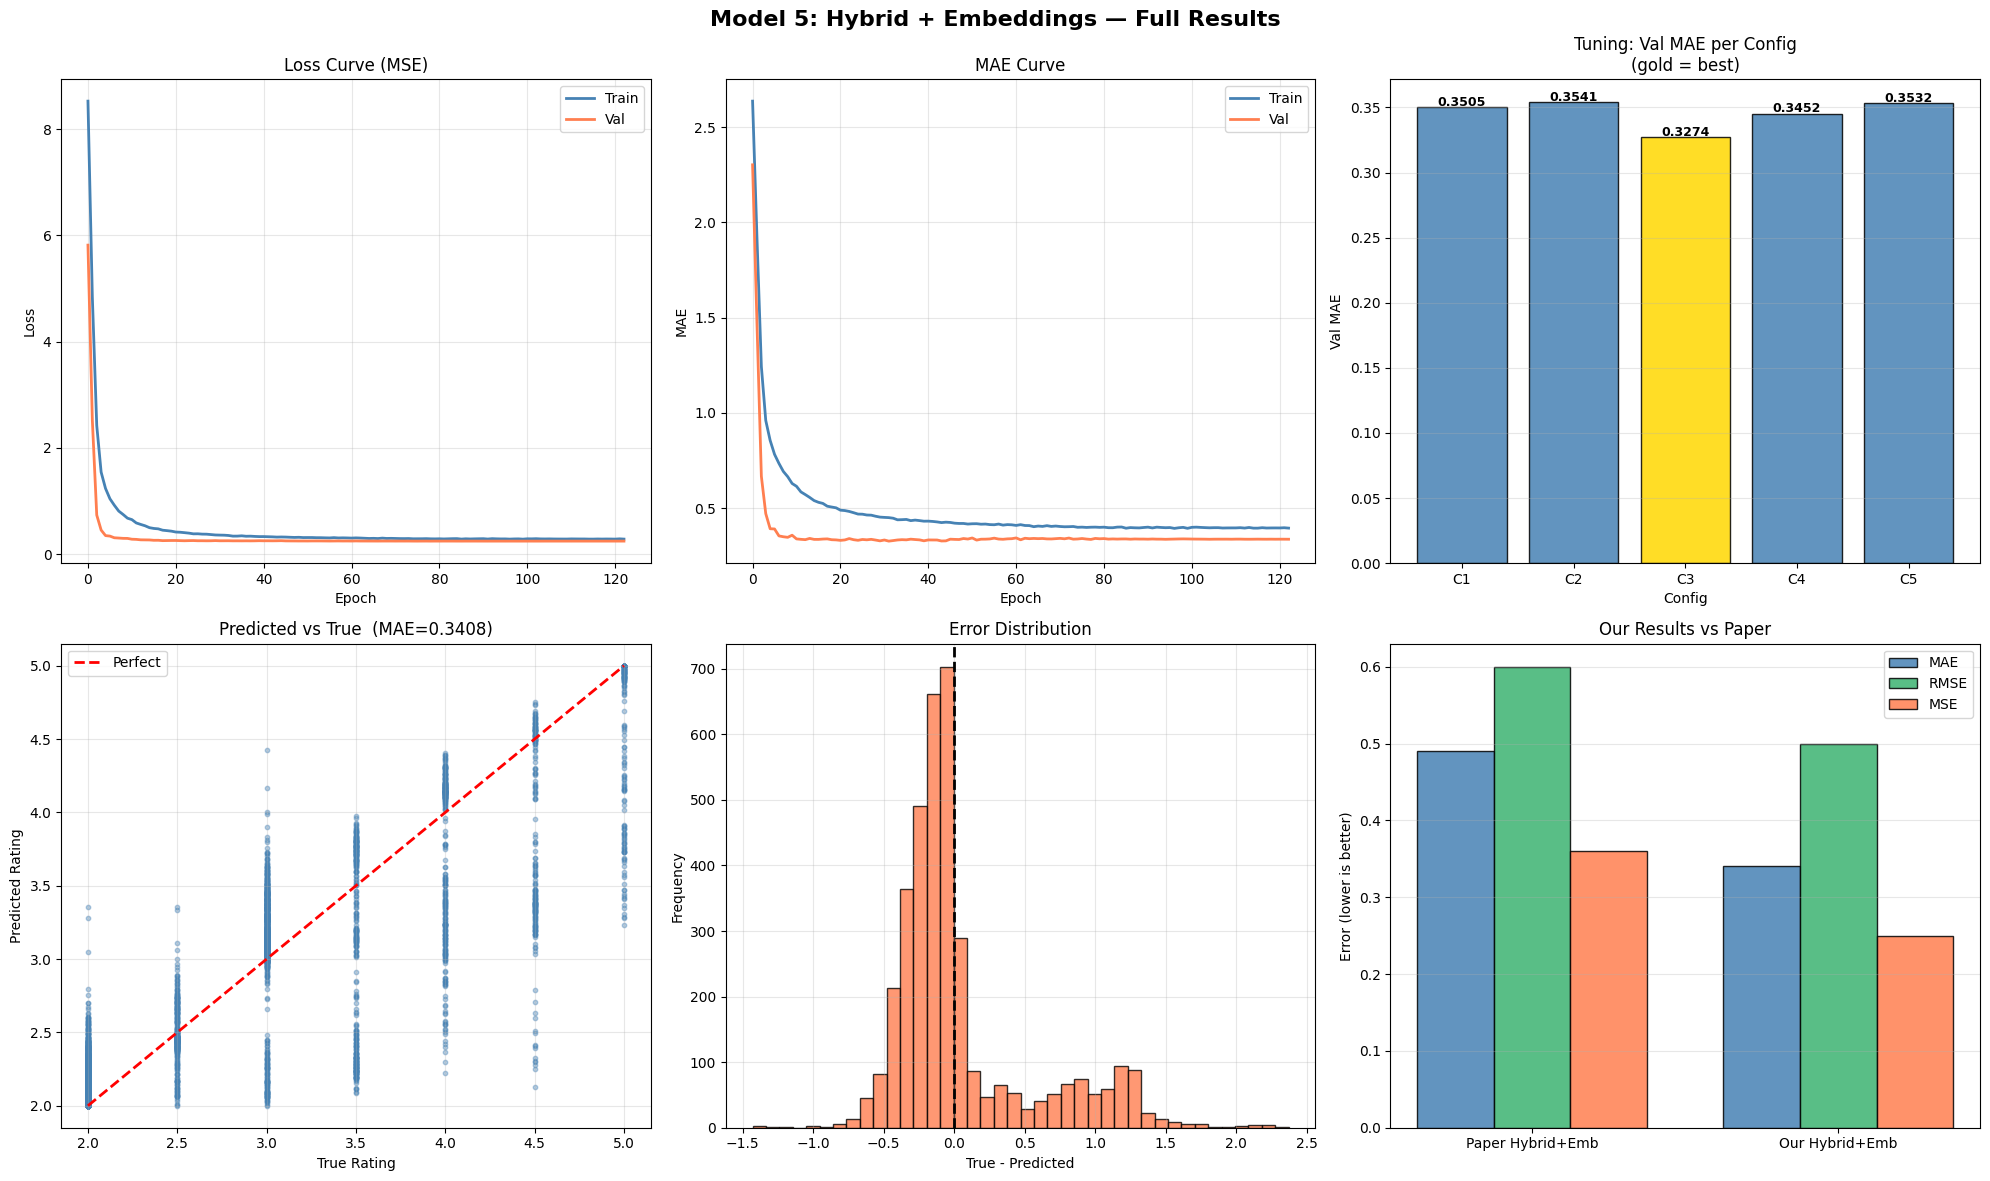


  FINAL SUMMARY — MODEL 5: HYBRID + EMBEDDINGS
  Best config      : {'units': [256, 128, 64], 'dropout': 0.3, 'lr': 0.001}
  Epochs ran       : 123
  Training time    : 0:00:45
  Best train loss  : 0.2835
  Best val loss    : 0.2463
  Best train MAE   : 0.3935
  Best val MAE     : 0.3266
  Test MAE         : 0.3408   (paper: 0.49)
  Test MSE         : 0.2496    (paper: 0.36)
  Test RMSE        : 0.4996   (paper: 0.60)
  Beats paper?     : YES


In [25]:
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model 5: Hybrid + Embeddings — Full Results',
             fontsize=16, fontweight='bold')

# Loss curve
axes[0,0].plot(history_m5.history['loss'],
               label='Train', linewidth=2, color='steelblue')
axes[0,0].plot(history_m5.history['val_loss'],
               label='Val',   linewidth=2, color='coral')
axes[0,0].set_title('Loss Curve (MSE)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# MAE curve
axes[0,1].plot(history_m5.history['mae'],
               label='Train', linewidth=2, color='steelblue')
axes[0,1].plot(history_m5.history['val_mae'],
               label='Val',   linewidth=2, color='coral')
axes[0,1].set_title('MAE Curve')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Tuning comparison
config_labels = [f"C{i+1}" for i in range(len(tune_results_m5))]
val_maes_m5   = [r['val_mae'] for r in tune_results_m5]
best_idx_m5   = val_maes_m5.index(min(val_maes_m5))
bar_colors_m5 = ['gold' if i == best_idx_m5 else 'steelblue'
                 for i in range(len(config_labels))]
bars = axes[0,2].bar(config_labels, val_maes_m5,
                      color=bar_colors_m5, edgecolor='black', alpha=0.85)
axes[0,2].set_title('Tuning: Val MAE per Config\n(gold = best)')
axes[0,2].set_xlabel('Config')
axes[0,2].set_ylabel('Val MAE')
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, val_maes_m5):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Predicted vs True
axes[1,0].scatter(y_te, y_pred_m5,
                  alpha=0.4, s=10, color='steelblue')
axes[1,0].plot([2, 5], [2, 5], 'r--', linewidth=2, label='Perfect')
axes[1,0].set_title(f'Predicted vs True  (MAE={mae_m5:.4f})')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Error distribution
errors_m5 = y_te - y_pred_m5
axes[1,1].hist(errors_m5, bins=40,
               color='coral', edgecolor='black', alpha=0.8)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution')
axes[1,1].set_xlabel('True - Predicted')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

# Our results vs paper
x_pos = np.arange(2)
w     = 0.25
axes[1,2].bar(x_pos - w, [0.49, mae_m5],  width=w, label='MAE',
              color='steelblue',      edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos,     [0.60, rmse_m5], width=w, label='RMSE',
              color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos + w, [0.36, mse_m5],  width=w, label='MSE',
              color='coral',          edgecolor='black', alpha=0.85)
axes[1,2].set_title('Our Results vs Paper')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Paper Hybrid+Emb', 'Our Hybrid+Emb'])
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saved_models/hybrid_emb_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  FINAL SUMMARY — MODEL 5: HYBRID + EMBEDDINGS")
print("="*65)
print(f"  Best config      : {best_cfg_m5}")
print(f"  Epochs ran       : {total_epochs_m5}")
print(f"  Training time    : {str(timedelta(seconds=int(time_m5)))}")
print(f"  Best train loss  : {best_train_loss_m5:.4f}")
print(f"  Best val loss    : {best_val_loss_m5:.4f}")
print(f"  Best train MAE   : {best_train_mae_m5:.4f}")
print(f"  Best val MAE     : {best_val_mae_m5:.4f}")
print(f"  Test MAE         : {mae_m5:.4f}   (paper: 0.49)")
print(f"  Test MSE         : {mse_m5:.4f}    (paper: 0.36)")
print(f"  Test RMSE        : {rmse_m5:.4f}   (paper: 0.60)")
print(f"  Beats paper?     : {'YES' if mae_m5 < 0.49 else 'NO'}")
print("="*65)